Avaliação do Modelo

Objetivo
- Vamos verificar se o melhor modelo atende aos critérios do projeto para churn.

O que vamos fazer?
1. carregar o melhor modelo salvo
2. avaliar no conjunto de teste
3. calcular métricas finais
4. mostrar matriz de confusão
5. verificar se atende aos critérios mínimos
6. registrar o resultado final

In [32]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

import matplotlib.pyplot as plt
import joblib

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [33]:
# Definir caminhos do projeto
try:
    notebook_dir = Path.cwd()
    if notebook_dir.name == 'notebooks':
        project_root = notebook_dir.parent
    else:
        project_root = notebook_dir
except:
    project_root = Path.cwd()

processed_dir = project_root / 'data' / 'processed'
artifacts_dir = project_root / 'artifacts'
models_dir = artifacts_dir / 'models'

model_path = models_dir / 'best_model.pkl'
test_path = processed_dir / '04_X_test_preprocessed.csv'

print(f'Projeto: {project_root}')
print(f'Modelo: {model_path}')
print(f'Dados de teste: {test_path}')

Projeto: c:\Temp\telco-churn-ml
Modelo: c:\Temp\telco-churn-ml\artifacts\models\best_model.pkl
Dados de teste: c:\Temp\telco-churn-ml\data\processed\04_X_test_preprocessed.csv


In [34]:
# Carregar o conjunto de teste

test_df = pd.read_csv(test_path)

X_test = test_df.drop(columns=['Churn'])
y_test = test_df['Churn']

print('Shape do X_test:', X_test.shape)
print('Shape do y_test:', y_test.shape)
print('\nDistribuição do alvo no teste:')
print(y_test.value_counts())

Shape do X_test: (1405, 45)
Shape do y_test: (1405,)

Distribuição do alvo no teste:
Churn
0    1033
1     372
Name: count, dtype: int64


In [35]:
# Carregar o melhor modelo salvo
model_bundle = joblib.load(model_path)
best_model = model_bundle['model']
threshold = model_bundle.get('threshold', 0.5)

print(type(best_model))
print(f'Threshold ajustado: {threshold:.2f}')
print('\nModelo carregado com sucesso!')

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
Threshold ajustado: 0.60

Modelo carregado com sucesso!


In [36]:
# Gerar previsões com o threshold ajustado

y_prob = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= threshold).astype(int)

print('Primeiras probabilidades:')
print(y_prob[:10])
print('\nPrimeiras predições com threshold:')
print(y_pred[:10])

Primeiras probabilidades:
[0.85933983 0.67675269 0.69962544 0.22503496 0.2108706  0.42254013
 0.20639434 0.90246043 0.03413111 0.07900969]

Primeiras predições com threshold:
[1 1 1 0 0 0 0 1 0 0]


In [37]:
# Calcular métricas finais
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

print('Métricas finais com threshold ajustado:')
print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1:        {f1:.4f}')
print(f'ROC-AUC:   {roc_auc:.4f}')

Métricas finais com threshold ajustado:
Accuracy:  0.7922
Precision: 0.5935
Recall:    0.6828
F1:        0.6350
ROC-AUC:   0.8419


In [38]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
print('Matriz de confusão:')
print(cm)

Matriz de confusão:
[[859 174]
 [118 254]]


In [39]:
# Verificar critérios do projeto
print('Critérios mínimos do projeto:')
print('AUC-ROC >= 0.75')
print('F1-Score >= 0.65')
print('Recall >= 0.60')

if roc_auc >= 0.75 and f1 >= 0.65 and recall >= 0.60:
    print('\n✅ Modelo aprovado de acordo com os critérios do projeto!')
else:
    print('\n⚠️ Modelo ainda precisa melhorar para atender ao critério do projeto.')

Critérios mínimos do projeto:
AUC-ROC >= 0.75
F1-Score >= 0.65
Recall >= 0.60

⚠️ Modelo ainda precisa melhorar para atender ao critério do projeto.


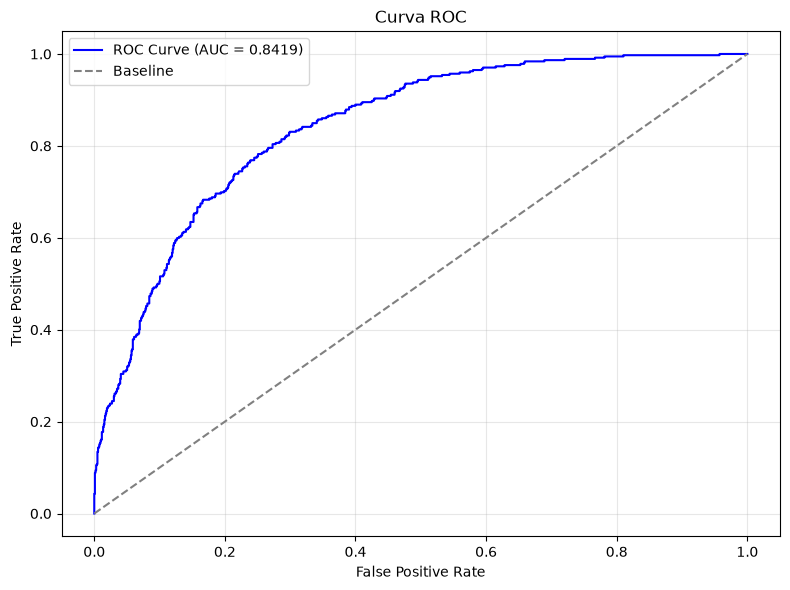

In [40]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Baseline')
plt.title('Curva ROC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [41]:
print('\nConclusão da avaliação:')
print(f'Acurácia: {accuracy:.4f}')
print(f'Precisão: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1: {f1:.4f}')
print(f'ROC-AUC: {roc_auc:.4f}')
print('\nResultado atual: o modelo ainda não atende aos critérios mínimos do projeto.')
print('Critérios: AUC-ROC >= 0.75, F1 >= 0.65 e Recall >= 0.60')
print('Próximo passo: ajustar threshold, testar outros modelos e refinar o treinamento antes de SHAP.')


Conclusão da avaliação:
Acurácia: 0.7922
Precisão: 0.5935
Recall: 0.6828
F1: 0.6350
ROC-AUC: 0.8419

Resultado atual: o modelo ainda não atende aos critérios mínimos do projeto.
Critérios: AUC-ROC >= 0.75, F1 >= 0.65 e Recall >= 0.60
Próximo passo: ajustar threshold, testar outros modelos e refinar o treinamento antes de SHAP.
